In [17]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [18]:
#Получите и визуализируйте (графически) статистику по датасету (включая количество, среднее значение, стандартное отклонение, минимум, максимум и различные квантили)."


In [19]:
data = pd.read_csv("/content/sample_data/california_housing_train.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [20]:
statistics = data.describe()
print(statistics)

          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1462.000000   
50%     -118.490000     34.250000           29.000000   2127.000000   
75%     -118.000000     37.720000           37.000000   3151.250000   
max     -114.310000     41.950000           52.000000  37937.000000   

       total_bedrooms    population    households  median_income  \
count    17000.000000  17000.000000  17000.000000   17000.000000   
mean       539.410824   1429.573941    501.221941       3.883578   
std        421.499452   1147.852959    384.520841       1.908157   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

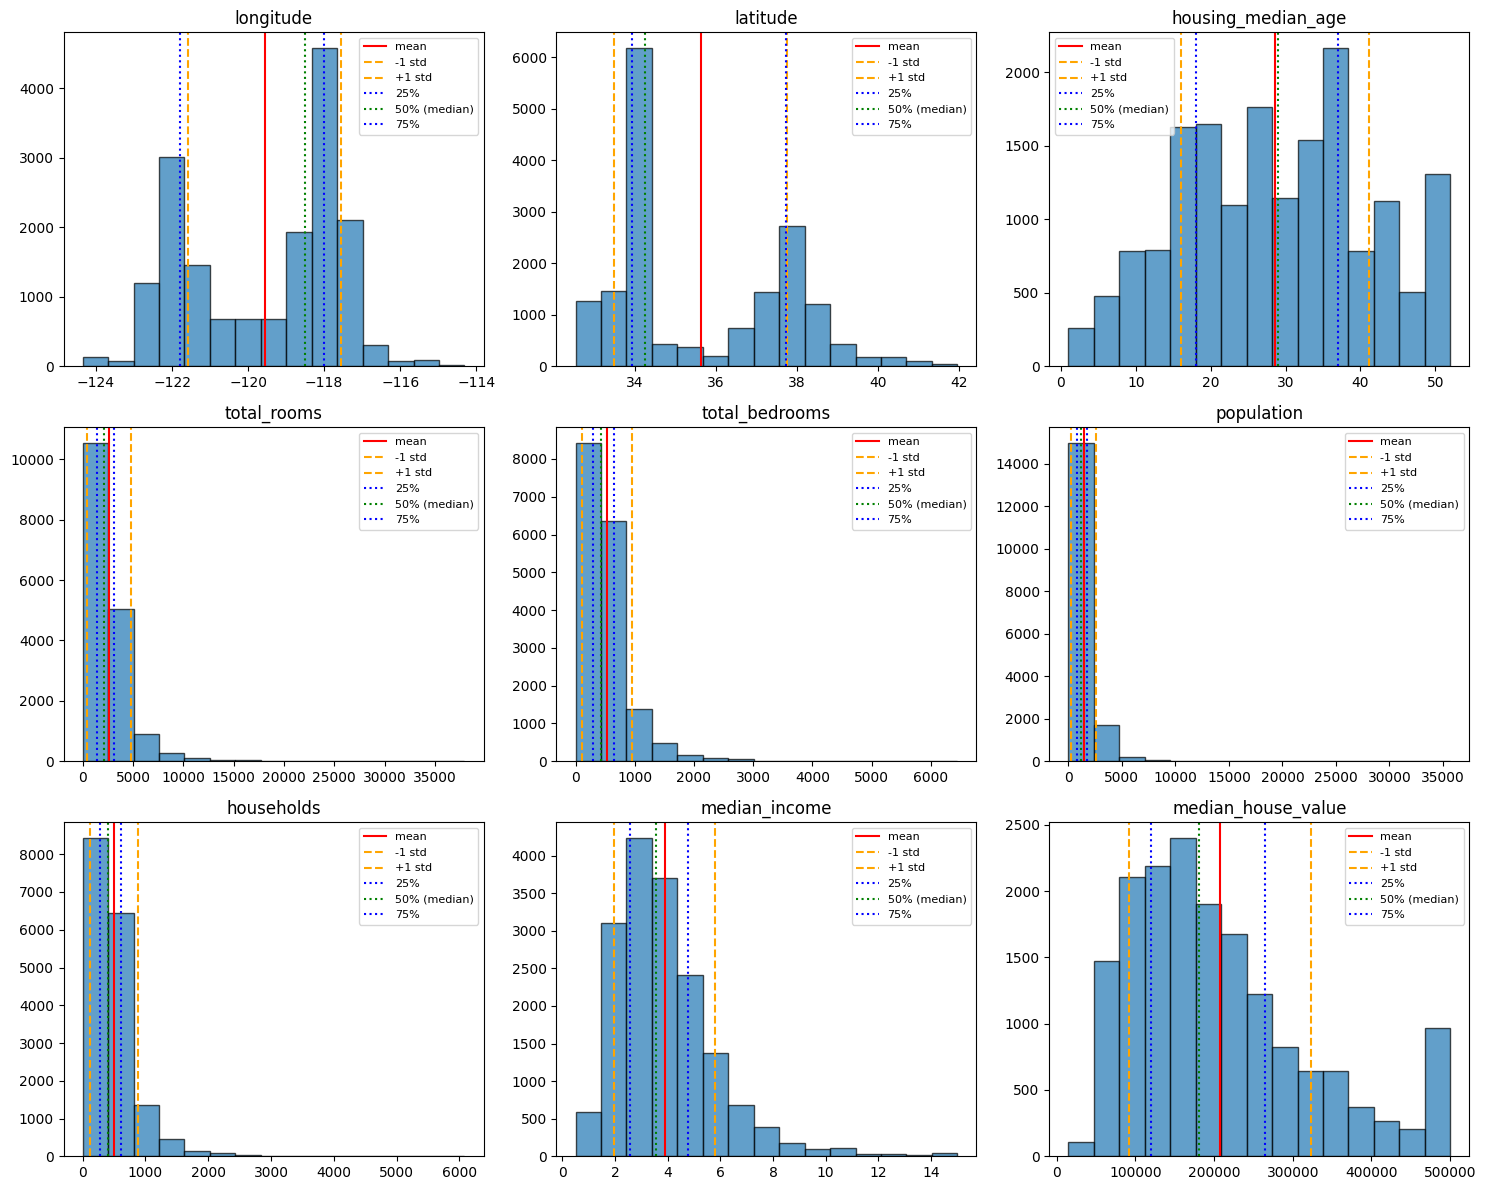

In [21]:
means = data.mean() # ср. знач
stds = data.std() # стандартное отклонение
mins = data.min()
maxs = data.max()
quantiles = data.quantile([0.25, 0.5, 0.75])


#правило Стерджеса n = 1 + [log2 N]
# Оптимальное количество интервалов для гистограммы
# Слишком мало бинов → потеря деталей
# Слишком много бинов → излишняя детализация, шум
rows_count = len(data)
bins_count = 1 + int(math.log(rows_count, 2))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
columns = data.columns

for i, col in enumerate(columns):
    ax = axes[i]

    values = data[col]
    hist = ax.hist(values, bins=bins_count, edgecolor="black", alpha=0.7)

    ax.axvline(means[col], color="red", linestyle="-", label="mean")
    ax.axvline(means[col] - stds[col], color="orange", linestyle="--", label="-1 std")
    ax.axvline(means[col] + stds[col], color="orange", linestyle="--", label="+1 std")
    ax.axvline(quantiles.loc[0.25, col], color="blue", linestyle=":", label="25%")
    ax.axvline(quantiles.loc[0.5, col], color="green", linestyle=":", label="50% (median)")
    ax.axvline(quantiles.loc[0.75, col], color="blue", linestyle=":", label="75%")

    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=8)

for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [22]:
#Проведите предварительную обработку данных, включая обработку отсутствующих значений, кодирование категориальных признаков и нормировка.


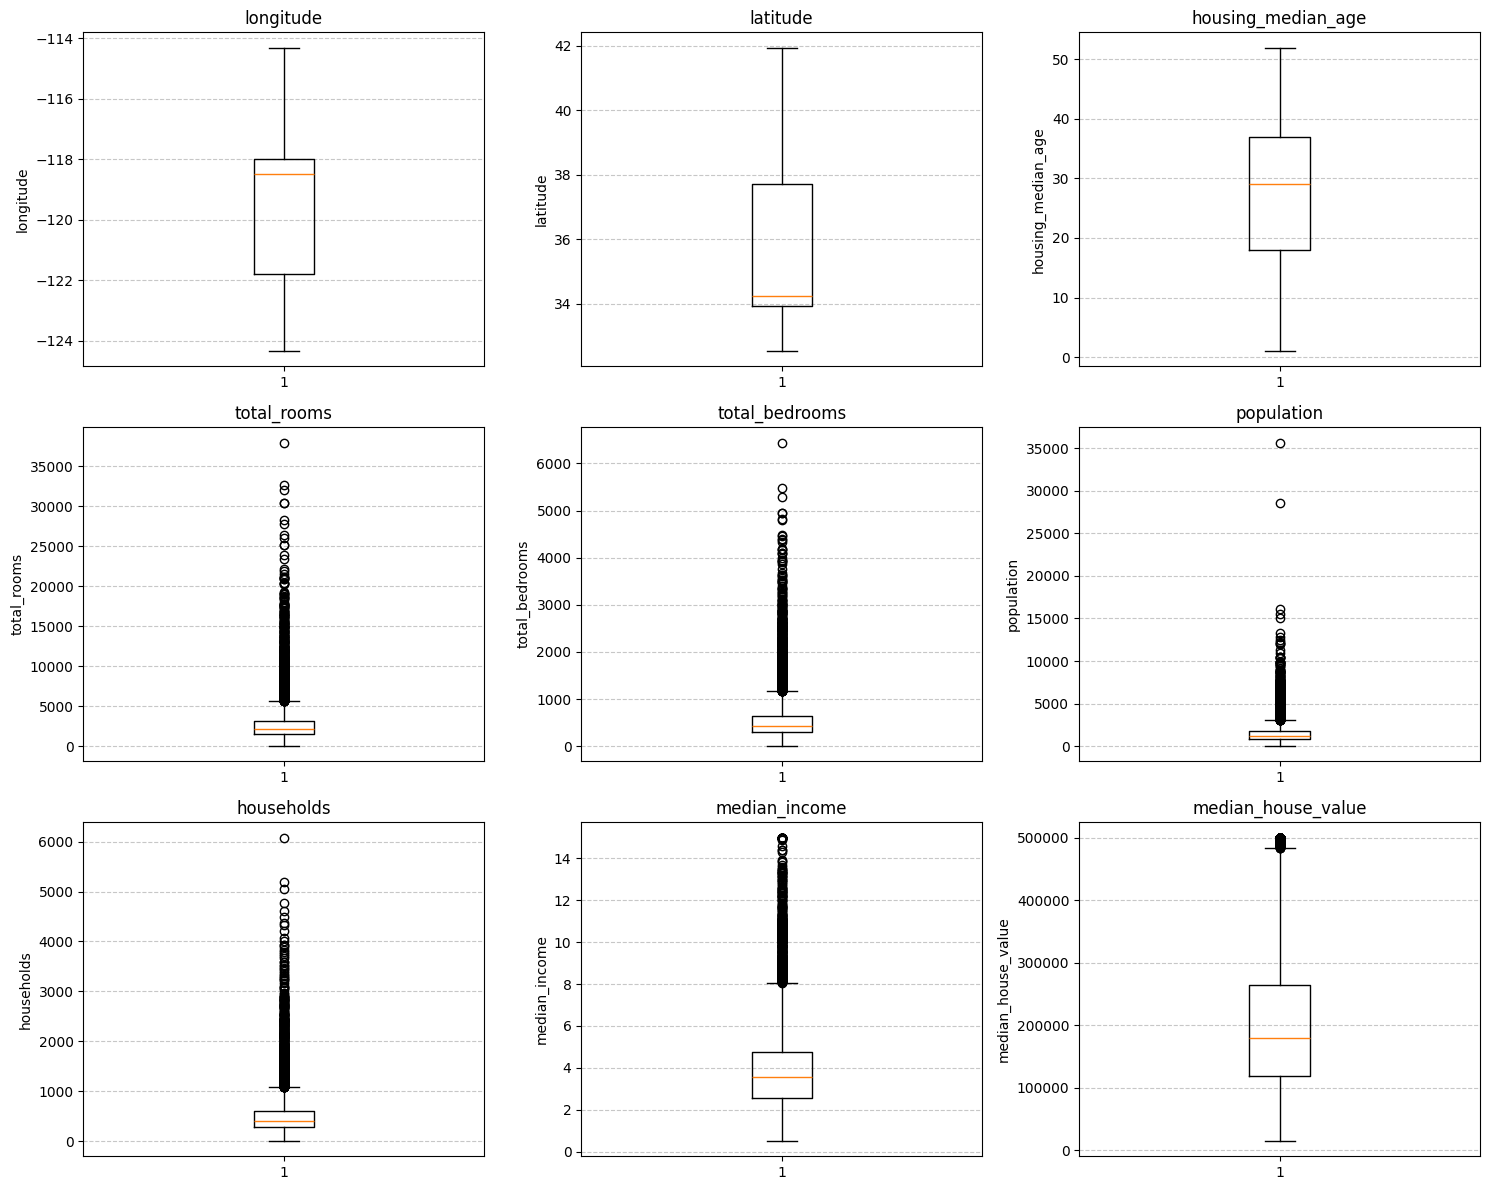

In [23]:
data = data.dropna()
#удаляем все строки с пропусками

features = data.columns

num_features = len(features)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.boxplot(data[feature])
    plt.title(feature)
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

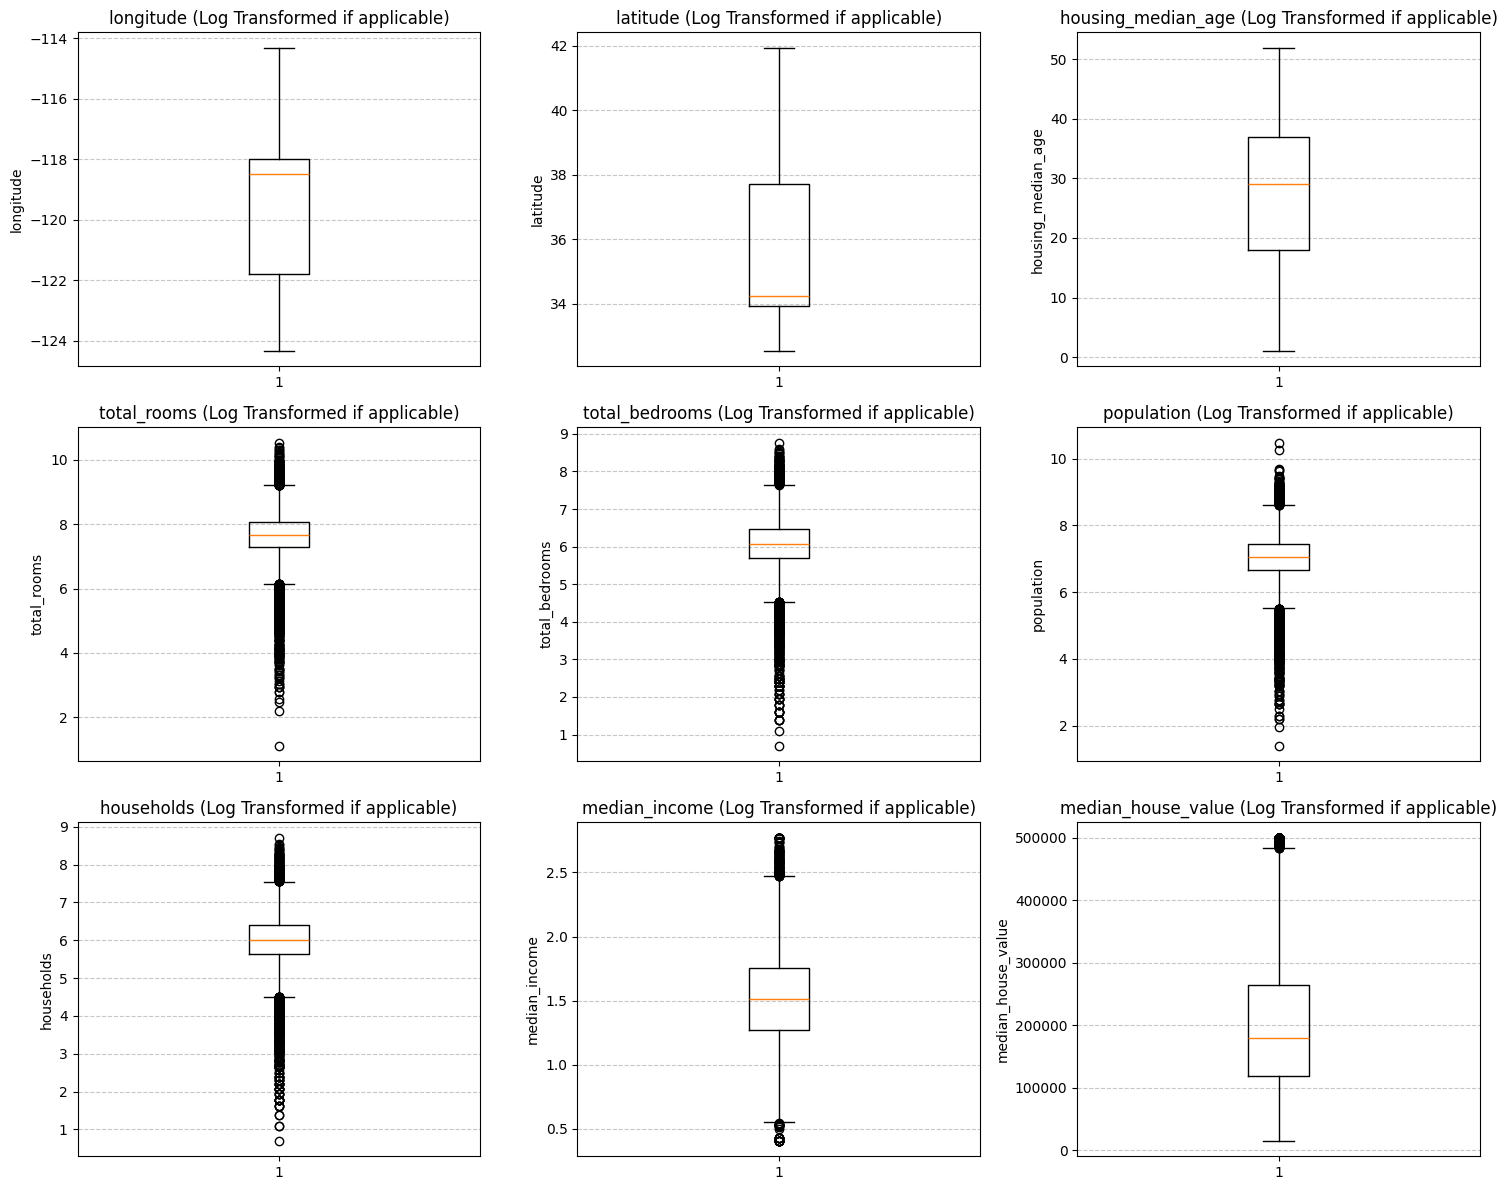

In [24]:
#Логарифмическое преобразование = распределение становится более равномерным
log_transform_cols = ["total_rooms", "total_bedrooms", "population", "households", "median_income"]
for col in log_transform_cols:
    data[col] = np.log1p(data[col]) # log1p Используется вместо log(x), чтобы избежать проблемы при x = 0 и более точная для малых значений
num_features = len(features)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.boxplot(data[feature])
    plt.title(f"{feature} (Log Transformed if applicable)")
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [25]:
#Разделение на обучающую и тестовую выборки -> Модель "видит" эти данные и подстраивает параметры
#Обучающая выборка (80%) — для обучения модели ->  Модель НЕ видит эти данные при обучении, Показывает, насколько хорошо модель работает на новых данных
#Тестовая выборка (20%) — для оценки обобщающей способности
X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]
np.random.seed(52)
n = len(data)
indices = np.random.permutation(n)
train_size = int(0.8 * n)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

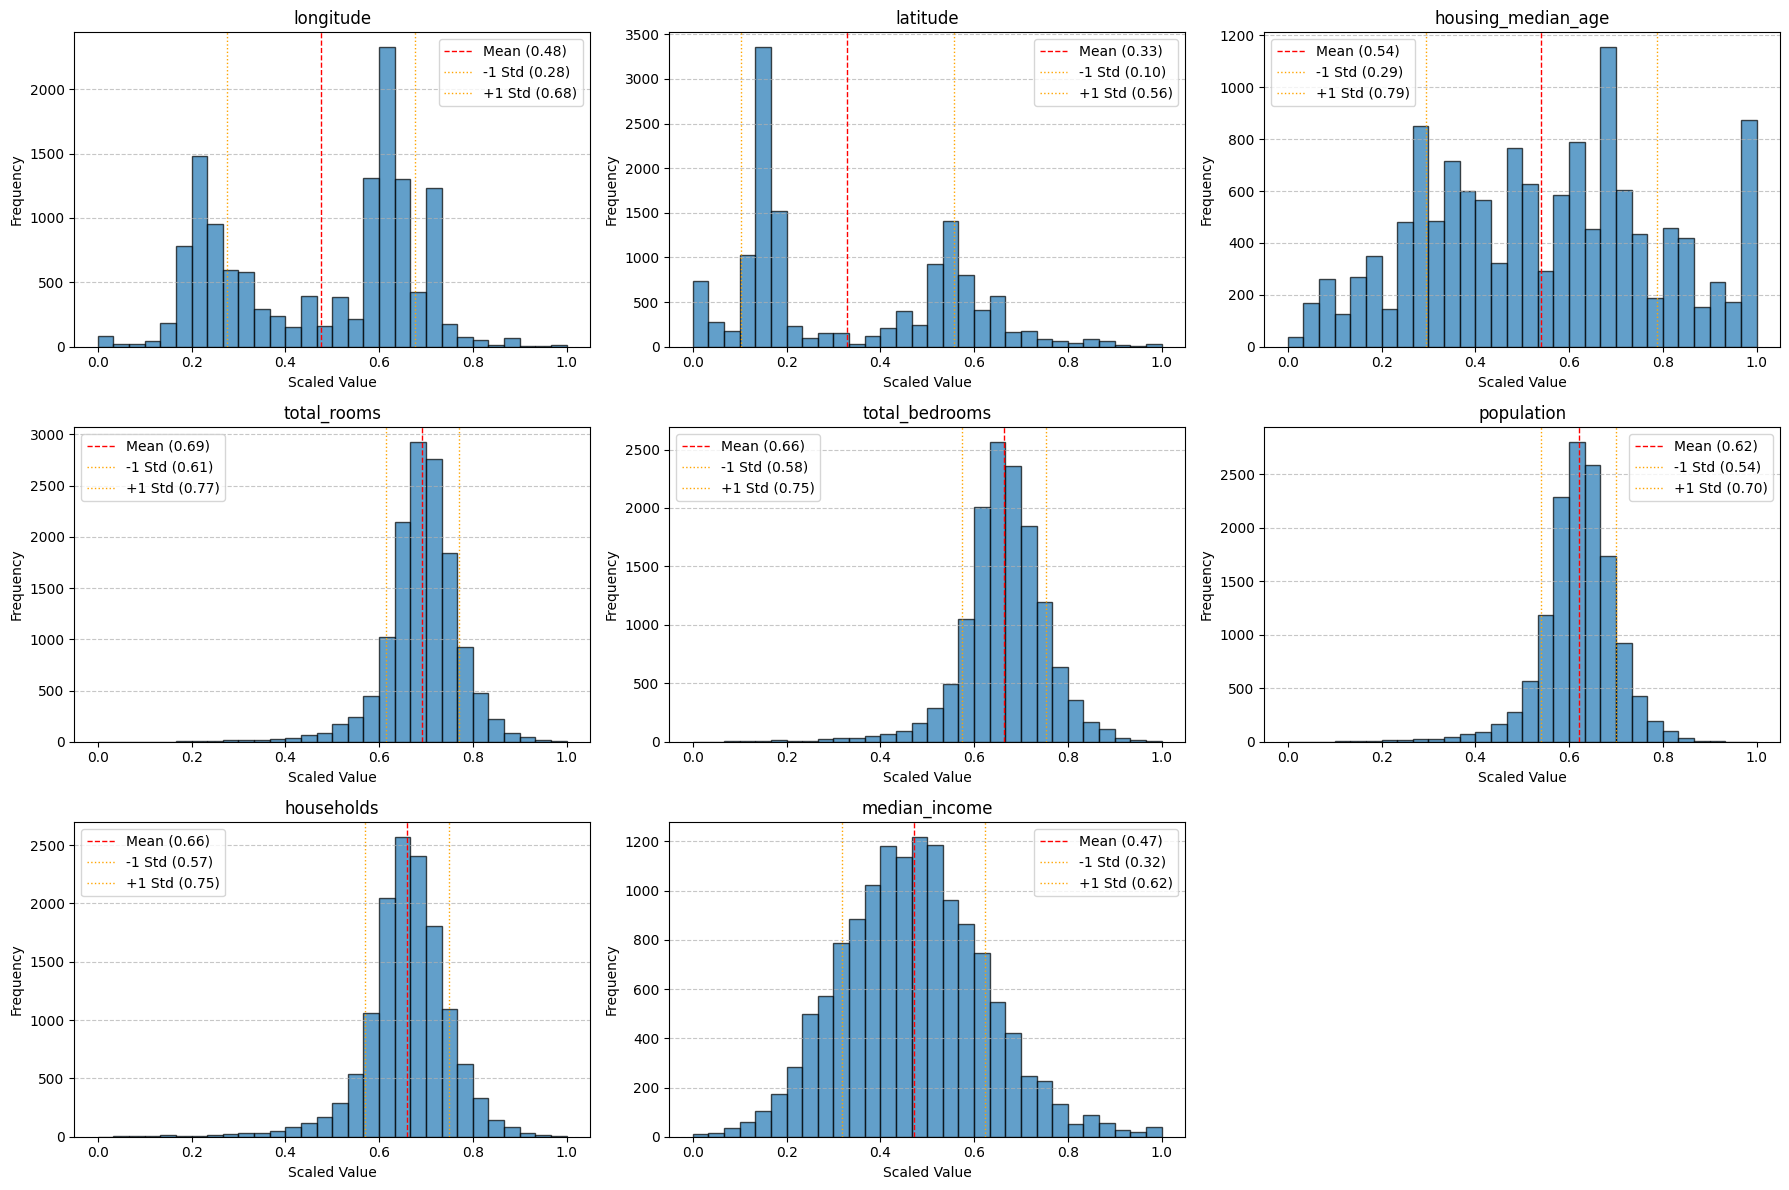

In [26]:
# Нормировка (масштабирование) -> Без нормировки признаки с большими значениями будут доминировать,
# Матричные операции работают лучше на нормированных данных, Избежание проблем с переполнением/исчезновением чисел, Алгоритмы оптимизации сходятся быстрее на нормированных данных
# Нормировку проводим только на обучающей выборке

train_min = X_train.min()
train_max = X_train.max()

X_train_scaled = (X_train - train_min) / (train_max - train_min)
X_test_scaled = (X_test - train_min) / (train_max - train_min)

num_features = X_train_scaled.shape[1]
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, feature in enumerate(X_train_scaled.columns):
    plt.subplot(num_rows, num_cols, i + 1)

    plt.hist(X_train_scaled[feature], bins=30, edgecolor='black', alpha=0.7)

    mean_val = X_train_scaled[feature].mean()
    std_val = X_train_scaled[feature].std()

    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean ({mean_val:.2f})')
    plt.axvline(mean_val - std_val, color='orange', linestyle='dotted', linewidth=1, label=f'-1 Std ({mean_val - std_val:.2f})')
    plt.axvline(mean_val + std_val, color='orange', linestyle='dotted', linewidth=1, label=f'+1 Std ({mean_val + std_val:.2f})')

    plt.title(feature)
    plt.xlabel('Scaled Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [27]:
'''
Постройте три модели с различными наборами признаков.
Для каждой модели проведите оценку производительности, используя метрику коэффициент детерминации, чтобы измерить, насколько хорошо модель соответствует данным.
Сравните результаты трех моделей и сделайте выводы о том, какие признаки работают лучше всего для каждой модели

'''

#Реализация линейной регрессии методом МНК

def mnk_cefs(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])

    # β = (X^T X)^{-1} X^T y
    beta = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)
    return beta.flatten()

def calc_res(X, beta):
    X = np.asarray(X, dtype=float)
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])
    return X_b @ beta

In [28]:
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


In [29]:
X1_train = X_train.values
X1_test  = X_test.values

beta1 = mnk_cefs(X1_train, y_train)
y_pred1 = calc_res(X1_test, beta1)
r2_1 = r2_score(y_test, y_pred1)

X2_train = X_train.drop(["longitude", "latitude"], axis=1).values
X2_test  = X_test.drop(["longitude", "latitude"], axis=1).values

beta2 = mnk_cefs(X2_train, y_train)
y_pred2 = calc_res(X2_test, beta2)
r2_2 = r2_score(y_test, y_pred2)

features3 = ["total_bedrooms", "median_income", "total_rooms",
             "housing_median_age", "longitude", "latitude"]

X3_train = X_train[features3].values
X3_test  = X_test[features3].values

beta3 = mnk_cefs(X3_train, y_train)
y_pred3 = calc_res(X3_test, beta3)
r2_3 = r2_score(y_test, y_pred3)

print(f"R² тест для модели 1 (все признаки): {r2_1:.4f}")
print(f"R² тест для модели 2 (без координат): {r2_2:.4f}")
print(f"R² тест для модели 3 (выбранные признаки): {r2_3:.4f}")

R² тест для модели 1 (все признаки): 0.6240
R² тест для модели 2 (без координат): 0.5640
R² тест для модели 3 (выбранные признаки): 0.5773


In [30]:
#оцениваем признаки для моделей
def evaluate_features(X_train, X_test, y_train, y_test, feature_names):
    beta = mnk_cefs(X_train, y_train)
    y_pred = calc_res(X_test, beta)
    base_r2 = r2_score(y_test, y_pred)

    print(f"\n Базовое R²: {base_r2:.4f}\n")

    results = []
    for i, feat in enumerate(feature_names):
        mask = [j for j in range(len(feature_names)) if j != i]

        X_train_red = X_train[:, mask]
        X_test_red = X_test[:, mask]

        beta_red = mnk_cefs(X_train_red, y_train)
        y_pred_red = calc_res(X_test_red, beta_red)
        r2_red = r2_score(y_test, y_pred_red)

        results.append((feat, base_r2, r2_red, base_r2 - r2_red))

    df = pd.DataFrame(results, columns=["Признак", "R² (все)", "R² (без признака)", "Потеря качества"])
    df = df.sort_values("Потеря качества", ascending=False).reset_index(drop=True)
    return df

In [31]:
features1 = list(X_train.columns)
X1_train = X_train[features1].values
X1_test  = X_test[features1].values
importance1 = evaluate_features(X1_train, X1_test, y_train, y_test, features1)
print("модель 1:") # лучшая R² = 0.6240
print(importance1)

features2 = list(X_train.drop(["longitude", "latitude"], axis=1).columns)
X2_train = X_train[features2].values
X2_test  = X_test[features2].values
importance2 = evaluate_features(X2_train, X2_test, y_train, y_test, features2)
print("\nмодель 2:")
print(importance2)

features3 = ["total_bedrooms", "median_income", "total_rooms",
             "housing_median_age", "longitude", "latitude"]
X3_train = X_train[features3].values
X3_test  = X_test[features3].values
importance3 = evaluate_features(X3_train, X3_test, y_train, y_test, features3)
print("\nмодель 3:")
print(importance3)

#Выводы

#Географические координаты важны — модели 1 и 3 лучше модели 2
#Полный набор признаков оптимален — модель 1 показывает лучший результат
#Не все признаки равнозначны — некоторые могут быть избыточными


#1. median_income — самый важный признак
#    - Доход жителей напрямую связан со стоимостью жилья
#    - Без него R² падает с 0.624 до 0.456 (падение на 27%)

#2. Географические координаты (latitude, longitude) — очень важны
#    - Расположение дома критично для стоимости
#    - Калифорния имеет большую территорию с разными рынками

# 3. population — умеренно важна
#    - Плотность населения влияет на стоимость

# 4. Остальные признаки — менее важны
#    - Могут быть коррелированы с другими признаками
#    - Например, households коррелирует с population

# Модель 2 (без координат):
#    - Без координат важность median_income возрастает (потеря 0.336)
#    - Это означает, что в модели 2 доход компенсирует отсутствие географической информации

# Модель 3 (выбранные признаки
#    - Результаты похожи на модель 1
#    - Подтверждает важность выбранных признаков


 Базовое R²: 0.6240

модель 1:
              Признак  R² (все)  R² (без признака)  Потеря качества
0       median_income  0.624024           0.455732         0.168292
1            latitude  0.624024           0.564148         0.059876
2           longitude  0.624024           0.568611         0.055413
3          population  0.624024           0.587019         0.037005
4      total_bedrooms  0.624024           0.611129         0.012895
5  housing_median_age  0.624024           0.615782         0.008242
6         total_rooms  0.624024           0.619749         0.004275
7          households  0.624024           0.622739         0.001285

 Базовое R²: 0.5640


модель 2:
              Признак  R² (все)  R² (без признака)  Потеря качества
0       median_income  0.564001           0.227726         0.336275
1          population  0.564001           0.529632         0.034369
2         total_rooms  0.564001           0.534411         0.029590
3  housing_median_age  0.564001           0.537244 

In [32]:
# Синтетический признак — новый признак, созданный из комбинации существующих признаков.
X_train = X_train.copy()
X_test = X_test.copy()

X_train.loc[:, "rooms_per_person"] = X_train["total_rooms"] / (X_train["population"] + 1e-5)
X_test.loc[:, "rooms_per_person"]  = X_test["total_rooms"] / (X_test["population"] + 1e-5)

features4 = ["total_bedrooms", "median_income", "total_rooms",
             "housing_median_age", "longitude", "latitude", "rooms_per_person"]

X4_train = X_train[features4].values
X4_test  = X_test[features4].values

importance4 = evaluate_features(X4_train, X4_test, y_train.values, y_test.values, features4)

print("\nсинтетич признак:")
print(importance4)

#  Выводы

# median_income:      потеря 0.1757 ← Все еще самый важный
# latitude:           потеря 0.0668
# longitude:          потеря 0.0635
# rooms_per_person:   потеря 0.0421 ← Новый признак важен = Показывает плотность комнат на человека
# total_bedrooms:     потеря 0.0243
# total_rooms:        потеря 0.0215
# housing_median_age: потеря 0.0087


 Базовое R²: 0.6195


синтетич признак:
              Признак  R² (все)  R² (без признака)  Потеря качества
0       median_income  0.619483           0.443831         0.175651
1            latitude  0.619483           0.552683         0.066800
2           longitude  0.619483           0.555945         0.063538
3    rooms_per_person  0.619483           0.577337         0.042145
4      total_bedrooms  0.619483           0.595157         0.024326
5         total_rooms  0.619483           0.597940         0.021543
6  housing_median_age  0.619483           0.610767         0.008715
